A lo largo de este notebook se realizará la implementación del Análisis Exploratorio de los Datos (EDA) y la limpieza si procede. 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_phq9 = pd.read_csv('../data/phq9.csv')
df_gad7 = pd.read_csv('../data/gad7.csv')
df_isi = pd.read_csv('../data/isi.csv')
df_pss = pd.read_csv('../data/pss.csv')
df_demographic = pd.read_csv('../data/demographic.csv')




Revisamos el cuestionario PHQ9 cuyas preguntas son:

Durante las dos últimas semanas, ¿qué tan seguido ha tenido molestias debido a los siguientes problemas?: 

1. Poco interés o placer en hacer las cosas. 
2. Se ha sentido decaído(a), deprimido(a), o sin esperanzas. 
3. Ha tenido dificultades para quedarse o permanecer dormido(a), o ha dormido demasiado. 
4. se ha sentido cansado(a).
5. Sin apetito o ha comido en exceso. 
6. Se ha sentido mal con usted mismo(a) - o que es un fracaso o que ha quedado mal con usted mismo(a) o con su familia. 
7. Ha tenido dificultad para concentrarse en ciertas actividades, tales como leer el periódico o ver la televisión. 
8. ¿Se ha movido o hablado tan lento que otras personas podrían haberlo notado? o lo contrario - muy inquieto(a) o agitado(a) que ha estado moviéndose mucho más de lo normal. 
9. Pensamientos de que estaría mejor muerto(a) o de lastimarse de alguna manera.  

Escala:
0 ningún día
1 varios días
2 más de la mitad de los días
3 casi todos los días




In [3]:
df_phq9.head()


,export_id,score,question1,time1,question2,time2,question3,time3,question4,time4,question5,time5,question6,time6,question7,time7,question8,time8,question9,time9
0,61793,0,0,2.47,0,1.23,0,1.12,0,1.73,0,4.74,0,1.32,0,0.16,0,12.99,0,4.00
1,61809,0,0,8.22,0,7.08,0,1.24,0,1.08,0,1.77,0,1.26,0,1.05,0,2.07,0,3.76
2,61737,0,0,1.88,0,1.65,0,1.00,0,1.18,0,0.81,0,1.29,0,4.17,0,1.29,0,4.58
3,61738,0,0,1.74,0,2.02,0,2.26,0,0.76,0,0.59,0,0.62,0,0.54,0,0.71,0,3.37
4,61739,2,1,5.54,0,2.57,0,1.30,0,2.19,0,1.08,1,3.33,0,3.13,0,3.63,0,4.31


Ahora revisaremos las respuestas del GAD_7 cuyas preguntas son:
Durante las últimas 2 semanas, ¿con qué frecuencia le han molestado los siguientes problemas?

1. Sentirse nervioso o ansioso. 
2. No poder detenerse o controlar la preocupación. 
3. Preocuparse demasiado por cosas diferentes. 
4. Dificultad para relajarse. 
5. Ser tan inquiero que es difícil quedaser quieto. 
6. Molestarse o irritarse con facilidad. 
7. Sentir miedo, como si algo horrible pudiera suceder. 

Cuyas respuestas pueden ser:
0 = nada, 
1 = varios días, 
2 = más de la mitad de los días, 
3 = casi todos los días. 



In [4]:
df_gad7.head()


,export_id,score,question1,time1,question2,time2,question3,time3,question4,time4,question5,time5,question6,time6,question7,time7
0,61793,0,0,2.19,0,8.10,0,0.95,0,0.81,0,0.72,0,0.80,0,3.28
1,61809,0,0,5.96,0,3.84,0,1.53,0,1.26,0,1.16,0,0.91,0,2.64
2,61737,0,0,5.03,0,1.72,0,3.47,0,1.85,0,2.38,0,1.84,0,7.37
3,61738,0,0,1.91,0,0.83,0,0.46,0,0.41,0,0.45,0,0.41,0,6.51
4,61739,0,0,1.51,0,2.37,0,0.89,0,0.50,0,0.51,0,0.54,0,2.57


Ahora revisaremos las preguntas del ISI: 

1. Indique la gravedad de su actual problema(s) de sueño:
 - Dificultad para quedarse dormido (0=nada, 1=leve, 2=moderado, 3=grave, 4=muy grave)
 - Dificultad para permanecer dormido/a (0=nada, 1=leve, 2=moderado, 3=grave, 4=muy grave)
 - Despertar temprano (0=nada, 1=leve, 2=moderado, 3=grave, 4=muy grave)

2. ¿Cómo de satisfecho/a está en la actualidad con su sueño?
0=muy satisfecho, 1=Satisfecho, 2=moderadamente satisfecho, 3=insatisfecho, 4=muy insatisfecho. 

3. ¿En qué medida considera que su problema de sueño interfiere en su funcionamiento diario (ej; fatiga durante el día, capacidad para las tareas cotidianas/trabajo, concentración, memoria, estado de ánimo, etc.)?
0=nada, 1=un poco, 2=algo, 3=mucho, 4=muchísimo.

4. ¿En qué medida cree que los demás se dan cuenta de que su problema de sueño le afecta a su calidad de vida?

0=nada, 1=un poco, 2=algo, 3=mucho, 4=muchísimo

5. ¿Cómo está de preocupado/a por su actual problema de sueño?
0=nada, 1=un poco, 2=algo, 3=mucho, 4=muchísimo


In [5]:
df_isi.head()

,export_id,score,question1,time1,question2,time2,question3,time3,question4,time4,question5,time5,question6,time6,question7,time7
0,61793,0,0,3.08,0,1.81,0,1.48,0,1.78,0,2.48,0,3.92,0,3.76
1,61809,0,0,1.23,0,0.93,0,1.37,0,1.95,0,4.09,0,1.74,0,3.22
2,61737,0,0,2.07,0,1.56,0,2.51,0,1.79,0,4.24,0,5.92,0,4.07
3,61738,0,0,1.34,0,0.42,0,2.20,0,0.76,0,0.82,0,1.22,0,2.20
4,61739,0,0,3.76,0,1.82,0,1.13,0,2.22,0,2.36,0,3.92,0,4.66


Igual haremos con el cuestionario PSS: 
Durante el último mes:
1. ¿Con qué frecuencia ha estado afectado/a por algo que ha ocurrido inesperadamente?
2. ¿Con qué frecuencia se ha sentido incapaz de controlar las cosas importantes en su vida?
3. ¿Con qué frecuencia se ha sentido nervioso o estresado?
4. ¿Con qué frecuencia ha manejado con éxito los pequeños problemas irritantes de la vida?
5. ¿Con qué frecuencia ha sentido que ha afrontado efectivamente los cambios importantes que han estado ocurriendo en su vida?
6. ¿Con qué frecuencia ha estado seguro sobre su capacidad para manejar sus problemas personales?
7. ¿Con qué frecuencia ha sentido que las cosas le van bien?
8. ¿Con qué frecuencia ha sentido que no podría afrontar todas las cosas que tenia que hacer?
9. ¿Con qué frecuencia ha podido controlar las dificultades de su vida?
10. ¿Con qué frecuencia se ha sentido que tenía todo bajo control?
11. ¿Con qué frecuencia ha estado enfadado porque las cosas que le han ocurrido estaban fuera de su control?
12. ¿Con qué frecuencia ha pensado sobre las cosas que le quedan por hacer?
13. ¿Con qué frecuencia ha podido controlar la forma de pasar el tiempo?

Respuestas: 
0=nunca, 1=casi nunca, 2=de vez en cuando, 3=a menudo, 4=muy a menudo. 



In [6]:
df_pss.head()

,export_id,score,question1,time1,question2,time2,question3,time3,question4,time4,...,question10,time10,question11,time11,question12,time12,question13,time13,question14,time14
0,61793,2,1,2.59,1,2.12,1,2.83,1,0.72,...,1,3.88,1,2.80,3,13.29,1,2.50,1,3.92
1,61809,21,2,5.10,1,3.97,1,0.97,5,0.77,...,5,2.78,1,1.91,2,3.29,2,5.04,1,3.62
2,61737,4,1,7.44,1,2.74,1,1.76,1,3.82,...,1,2.73,1,5.56,5,13.30,1,2.90,1,5.98
3,61738,28,1,1.18,1,1.25,1,0.59,5,0.50,...,5,0.55,1,1.04,1,0.34,5,0.48,1,2.15
4,61739,16,1,1.94,1,0.53,2,0.39,2,4.28,...,2,3.91,3,3.58,3,2.79,2,1.94,2,5.74


Ahora revisamos qué datos demográficos se recogieron y con qué puntuaciones. 



In [7]:
df_demographic.head()


,export_id,gender,age,edu,smoke,drink
0,61793,female,19.0,bachelor's degree,never smokes,never drinks
1,61809,female,18.0,bachelor's degree,never smokes,never drinks
2,61737,male,40.0,master's degree,never smokes,drinks occasionally (less than once a week)
3,61738,female,23.0,bachelor's degree,never smokes,never drinks
4,61739,female,21.0,bachelor's degree,never smokes,never drinks


In [8]:
df_phq9.info()


<class 'pandas.DataFrame'>
RangeIndex: 24292 entries, 0 to 24291
Data columns (total 20 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   export_id  24292 non-null  int64  
 1   score      24292 non-null  int64  
 2   question1  24292 non-null  int64  
 3   time1      24292 non-null  float64
 4   question2  24292 non-null  int64  
 5   time2      24292 non-null  float64
 6   question3  24292 non-null  int64  
 7   time3      24292 non-null  float64
 8   question4  24292 non-null  int64  
 9   time4      24292 non-null  float64
 10  question5  24292 non-null  int64  
 11  time5      24292 non-null  float64
 12  question6  24292 non-null  int64  
 13  time6      24292 non-null  float64
 14  question7  24292 non-null  int64  
 15  time7      24292 non-null  float64
 16  question8  24292 non-null  int64  
 17  time8      24292 non-null  float64
 18  question9  24292 non-null  int64  
 19  time9      24292 non-null  float64
dtypes: float64(9), in

In [9]:
df_gad7.info()


<class 'pandas.DataFrame'>
RangeIndex: 24292 entries, 0 to 24291
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   export_id  24292 non-null  int64  
 1   score      24292 non-null  int64  
 2   question1  24292 non-null  int64  
 3   time1      24292 non-null  float64
 4   question2  24292 non-null  int64  
 5   time2      24292 non-null  float64
 6   question3  24292 non-null  int64  
 7   time3      24292 non-null  float64
 8   question4  24292 non-null  int64  
 9   time4      24292 non-null  float64
 10  question5  24292 non-null  int64  
 11  time5      24292 non-null  float64
 12  question6  24292 non-null  int64  
 13  time6      24292 non-null  float64
 14  question7  24292 non-null  int64  
 15  time7      24292 non-null  float64
dtypes: float64(7), int64(9)
memory usage: 3.0 MB


In [10]:
df_isi.info()


<class 'pandas.DataFrame'>
RangeIndex: 24292 entries, 0 to 24291
Data columns (total 16 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   export_id  24292 non-null  int64  
 1   score      24292 non-null  int64  
 2   question1  24292 non-null  int64  
 3   time1      24292 non-null  float64
 4   question2  24292 non-null  int64  
 5   time2      24292 non-null  float64
 6   question3  24292 non-null  int64  
 7   time3      24292 non-null  float64
 8   question4  24292 non-null  int64  
 9   time4      24292 non-null  float64
 10  question5  24292 non-null  int64  
 11  time5      24292 non-null  float64
 12  question6  24292 non-null  int64  
 13  time6      24292 non-null  float64
 14  question7  24292 non-null  int64  
 15  time7      24292 non-null  float64
dtypes: float64(7), int64(9)
memory usage: 3.0 MB


In [11]:
df_pss.info()


<class 'pandas.DataFrame'>
RangeIndex: 24292 entries, 0 to 24291
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   export_id   24292 non-null  int64  
 1   score       24292 non-null  int64  
 2   question1   24292 non-null  int64  
 3   time1       24292 non-null  float64
 4   question2   24292 non-null  int64  
 5   time2       24292 non-null  float64
 6   question3   24292 non-null  int64  
 7   time3       24292 non-null  float64
 8   question4   24292 non-null  int64  
 9   time4       24292 non-null  float64
 10  question5   24292 non-null  int64  
 11  time5       24292 non-null  float64
 12  question6   24292 non-null  int64  
 13  time6       24292 non-null  float64
 14  question7   24292 non-null  int64  
 15  time7       24292 non-null  float64
 16  question8   24292 non-null  int64  
 17  time8       24292 non-null  float64
 18  question9   24292 non-null  int64  
 19  time9       24292 non-null  float64


In [12]:
df_demographic.info()


<class 'pandas.DataFrame'>
RangeIndex: 24292 entries, 0 to 24291
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   export_id  24292 non-null  int64  
 1   gender     24292 non-null  str    
 2   age        24292 non-null  float64
 3   edu        24292 non-null  str    
 4   smoke      24292 non-null  str    
 5   drink      24292 non-null  str    
dtypes: float64(1), int64(1), str(4)
memory usage: 1.1 MB


Los datos están completos y limpios, no hay necesidad de imputar. 

A continuación revisamos las distribuciones:


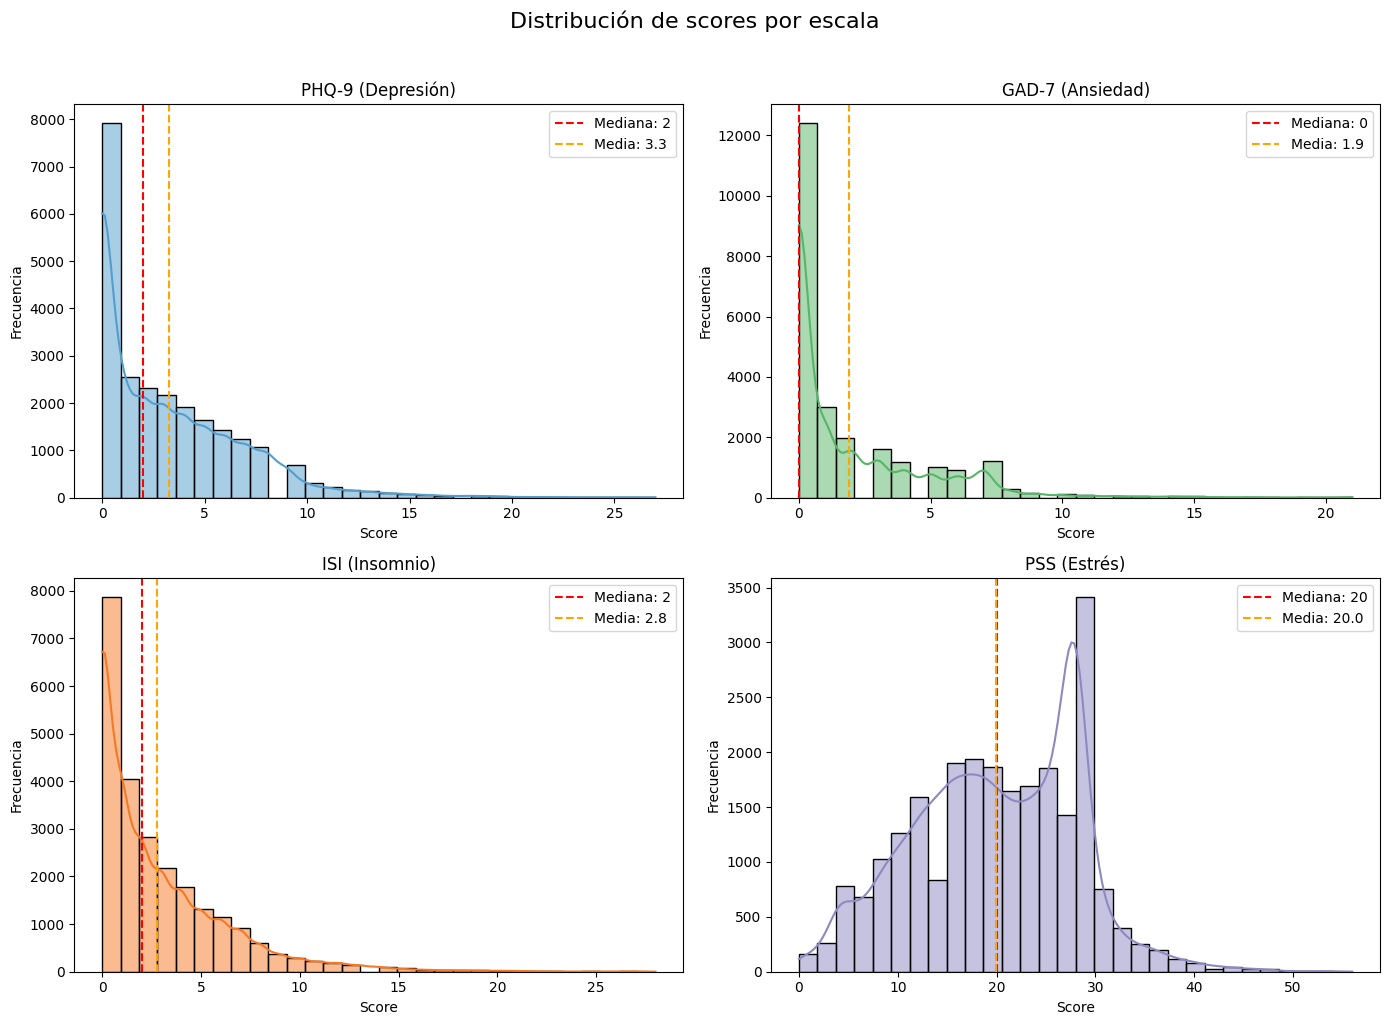

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribución de scores por escala', fontsize=16, y=1.02)

escalas = [
    (df_phq9, 'PHQ-9 (Depresión)', 'Blues', axes[0,0]),
    (df_gad7, 'GAD-7 (Ansiedad)',  'Greens', axes[0,1]),
    (df_isi,  'ISI (Insomnio)',    'Oranges', axes[1,0]),
    (df_pss,  'PSS (Estrés)',      'Purples', axes[1,1])
]

for df, titulo, color, ax in escalas:
    sns.histplot(df['score'], bins=30, kde=True, color=sns.color_palette(color)[3], ax=ax)
    ax.axvline(df['score'].median(), color='red', linestyle='--', linewidth=1.5, label=f'Mediana: {df["score"].median():.0f}')
    ax.axvline(df['score'].mean(), color='orange', linestyle='--', linewidth=1.5, label=f'Media: {df["score"].mean():.1f}')
    ax.set_title(titulo)
    ax.set_xlabel('Score')
    ax.set_ylabel('Frecuencia')
    ax.legend()

plt.tight_layout()
plt.show()

In [14]:
(df_phq9[[f'time{i}' for i in range(1,10)]] < 1)

,time1,time2,time3,time4,time5,time6,time7,time8,time9
0,False,False,False,False,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,True,False,False,False,False
3,False,False,False,True,True,True,True,True,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
24287,False,False,False,False,False,False,False,False,False
24288,False,False,False,False,False,False,False,False,False
24289,False,False,False,False,False,False,False,False,False
24290,False,False,False,False,False,False,False,False,False


In [15]:
time_cols_phq9 = [f'time{i}' for i in range(1,10)]
time_phq9 = df_phq9[time_cols_phq9]

print("==Media y desviación típica por item - PHQ-9 == ")
print(time_phq9.describe().loc[['mean', 'std']])

==Media y desviación típica por item - PHQ-9 == 
          time1      time2      time3      time4     time5      time6  \
mean   9.689925   4.701156   3.856209   2.953732  2.676187   3.416673   
std   53.984176  19.859486  15.370622  10.546879  9.810274  12.060415   

          time7      time8      time9  
mean   4.080823   5.310333   5.889050  
std   26.691137  34.259408  11.712809  


In [16]:
time_cols_gad7 = [f'time{i}' for i in range(1,8)]
time_gad7 = df_gad7[time_cols_gad7]

print("==Media y desviación típica por item - GAD7 == ")
print(time_gad7.describe().loc[['mean', 'std']])

==Media y desviación típica por item - GAD7 == 
          time1      time2      time3     time4     time5     time6      time7
mean   7.198003   4.444812   2.799908  2.026969  2.190658  2.053797   5.287107
std   39.981299  38.403495  10.706078  3.746773  4.603555  6.024952  10.429370


In [17]:
time_cols_isi = [f'time{i}' for i in range(1,8)]
time_isi = df_isi[time_cols_isi]

print("==Media y desviación típica por item - ISI == ")
print(time_isi.describe().loc[['mean', 'std']])

==Media y desviación típica por item - ISI == 
          time1      time2      time3     time4      time5      time6  \
mean   4.549404   2.368938   2.291580  3.012750   5.972153   6.151019   
std   45.490719  13.549903  10.639362  7.073833  41.124598  13.141077   

          time7  
mean   6.032402  
std   15.047951  


In [18]:
time_cols_pss = [f'time{i}' for i in range(1,15)]
time_pss = df_pss[time_cols_pss]

print("==Media y desviación típica por item - PSS == ")
print(time_pss.describe().loc[['mean', 'std']])

==Media y desviación típica por item - PSS == 
          time1      time2      time3      time4      time5      time6  \
mean   7.248365   3.728152   2.596815   4.799341   6.605855   4.525542   
std   44.016735  15.374909  12.191156  10.375114  30.961019  42.419975   

          time7      time8     time9     time10     time11     time12  \
mean   3.232517   6.569370  4.260187   3.901943   5.178981   5.279655   
std   13.731344  23.341122  8.512488  16.060839  93.354989  22.984788   

        time13     time14  
mean  3.501852   6.555647  
std   9.519397  13.223442  


Podemos observar que las medias y las desviaciones típicas son demasiado dispares, de manera que no podemos sacar conclusiones con respecto a estas. 

Pasamos a comprobar la mediana y la MAD (desviación absoluta respecto a la mediana). 
Esto nos garantiza elegir el punto que deja el 50% de las observaciones por debajo, de manera que no se deja afectar tanto por las puntuaciones extremas como la media. 



In [19]:
print(df_phq9[[f'time{i}' for i in range(1,10)]].median())

time1    5.61
time2    3.29
time3    2.48
time4    2.00
time5    1.85
time6    2.28
time7    2.85
time8    3.26
time9    4.71
dtype: float64


Se valora la posibilidad de realizar la mediana por cada item o pregunta, dado que se observa que las primeras preguntas tardan más, pero como lo que se busca es un criterio de exclusión de aquellas personas que "pudieran responder casi sin leer las preguntas" elegimos el formato de tiempo total. 

In [20]:
df_phq9['total_time'] = df_phq9[[f'time{i}' for i in range(1, 10)]].sum(axis=1)
print(df_phq9['total_time'].median())

33.72


La mediana del tiempo total es 33.72s, ahora evaluamos cuánto se aleja cada participante de la mediana total. 

In [21]:
mediana_total = df_phq9['total_time'].median()
df_phq9['desviacion_mediana'] = abs(df_phq9['total_time'] - mediana_total)
print(df_phq9['desviacion_mediana'].head(10))

0     3.96
1     6.19
2    15.87
3    21.11
4     6.64
5    11.26
6    18.28
7    14.66
8    24.28
9    17.93
Name: desviacion_mediana, dtype: float64


y calculamos la desviación absoluta con respecto a la mediana (MAD)

In [22]:
MAD = df_phq9['desviacion_mediana'].median()
print(f"MAD: {MAD:.2f}")

MAD: 11.81


Ahora cogemos el umbral que aplican en el paper para designar outliers (5 veces alejadas de la MAD). Estos se van a valorar tanto para los que están por encima, como para los que están muy por debajo. 


In [23]:
umbral = 5 * MAD
print(f"Umbral: {umbral:.2f} segundos sobre la mediana")

outliers_phq9 = df_phq9[df_phq9['desviacion_mediana'] > umbral]
print(f"Participantes outlier: {len(outliers_phq9)} de {len(df_phq9)} ({len(outliers_phq9)/len(df_phq9)*100:.2f}%)")

Umbral: 59.05 segundos sobre la mediana
Participantes outlier: 955 de 24292 (3.93%)


Vemos que 955 participantes (3.93%) se consideran outliers, pero aún no sabemos si los umbrales son de personas que tardaron demasiado o demasiado poco. 

In [24]:
print(f"Mediana total: {mediana_total:.2f}s")
print(f"Umbral superior: {mediana_total + umbral:.2f}s")
print(f"Umbral inferior: {mediana_total - umbral:.2f}s")
print(f"\nOutliers por cola:")
print(f"  Cola baja (muy rápidos): {len(df_phq9[df_phq9['total_time'] < mediana_total - umbral])}")
print(f"  Cola alta (muy lentos):  {len(df_phq9[df_phq9['total_time'] > mediana_total + umbral])}")

Mediana total: 33.72s
Umbral superior: 92.77s
Umbral inferior: -25.33s

Outliers por cola:
  Cola baja (muy rápidos): 0
  Cola alta (muy lentos):  954


La gran mayoría (954) son personas que tardaron mucho en completar las preguntas. Esto elimina la opción de quitar a los que respondieron sin leer ya que no hay ninguno que aparezca por tiempos demasiado cortos. Esto no nos ayuda a resolver el problema que buscábamos, por lo que probamos otros caminos. Buscamos personas que respondan por debajo de umbral perceptivo humano en TODAS las preguntas. 

In [25]:
time_cols_phq9 = [f'time{i}' for i in range(1, 10)]

# Cuántos ítems por debajo de 2s tiene cada participante
df_phq9['items_rapidos'] = (df_phq9[time_cols_phq9] < 2).sum(axis=1)

# Distribución de ese conteo
print(df_phq9['items_rapidos'].value_counts().sort_index())

items_rapidos
0    5148
1    4224
2    3390
3    2611
4    2186
5    2047
6    2226
7    1767
8     648
9      45
Name: count, dtype: int64


In [26]:
for n in range(5, 10):
    grupo = df_phq9[df_phq9['items_rapidos'] >= n]
    print(f"≥{n} ítems rápidos: {len(grupo)} participantes ({len(grupo)/len(df_phq9)*100:.1f}%) | score medio: {grupo['score'].mean():.2f}")

≥5 ítems rápidos: 6733 participantes (27.7%) | score medio: 1.30
≥6 ítems rápidos: 4686 participantes (19.3%) | score medio: 1.12
≥7 ítems rápidos: 2460 participantes (10.1%) | score medio: 0.95
≥8 ítems rápidos: 693 participantes (2.9%) | score medio: 1.06
≥9 ítems rápidos: 45 participantes (0.2%) | score medio: 2.56


In [27]:
grupo_9 = df_phq9[df_phq9['items_rapidos'] == 9]
print(grupo_9['score'].describe())
print()
print(grupo_9['score'].value_counts().sort_index())

count    45.000000
mean      2.555556
std       5.353654
min       0.000000
25%       0.000000
50%       0.000000
75%       2.000000
max      26.000000
Name: score, dtype: float64

score
0     30
1      3
2      1
3      2
6      1
7      3
9      1
13     1
14     1
15     1
26     1
Name: count, dtype: int64


In [28]:
mascara = (df_phq9['items_rapidos'] >= 7) & (df_phq9['score'] <= 2)
sospechosos = df_phq9[mascara]
print(f"Participantes con ≥7 ítems rápidos Y score ≤2: {len(sospechosos)} ({len(sospechosos)/len(df_phq9)*100:.1f}%)")
print()
print(sospechosos['score'].value_counts().sort_index())

Participantes con ≥7 ítems rápidos Y score ≤2: 2201 (9.1%)

score
0    1974
1     176
2      51
Name: count, dtype: int64


In [29]:
# Identificar sospechosos en cada escala
def get_sospechosos(df, n_items):
    cols = [f'time{i}' for i in range(1, n_items + 1)]
    items_rapidos = (df[cols] < 2).sum(axis=1)
    mascara = (items_rapidos >= round(n_items * 0.75)) & (df['score'] <= 2)
    return set(df[mascara]['export_id'])

sospechosos_phq9 = get_sospechosos(df_phq9, 9)
sospechosos_gad7 = get_sospechosos(df_gad7, 7)
sospechosos_isi  = get_sospechosos(df_isi, 7)
sospechosos_pss  = get_sospechosos(df_pss, 14)

print(f"Sospechosos PHQ-9: {len(sospechosos_phq9)}")
print(f"Sospechosos GAD-7: {len(sospechosos_gad7)}")
print(f"Sospechosos ISI:   {len(sospechosos_isi)}")
print(f"Sospechosos PSS:   {len(sospechosos_pss)}")
print()
print(f"Sospechosos en las 4 escalas: {len(sospechosos_phq9 & sospechosos_gad7 & sospechosos_isi & sospechosos_pss)}")
print(f"Sospechosos en al menos 3:    {len(sospechosos_phq9 & sospechosos_gad7 & sospechosos_isi | sospechosos_phq9 & sospechosos_gad7 & sospechosos_pss | sospechosos_phq9 & sospechosos_isi & sospechosos_pss | sospechosos_gad7 & sospechosos_isi & sospechosos_pss)}")
print(f"Sospechosos en al menos 2:    {len(sospechosos_phq9 & sospechosos_gad7 | sospechosos_phq9 & sospechosos_isi | sospechosos_phq9 & sospechosos_pss | sospechosos_gad7 & sospechosos_isi | sospechosos_gad7 & sospechosos_pss | sospechosos_isi & sospechosos_pss)}")

Sospechosos PHQ-9: 2201
Sospechosos GAD-7: 6969
Sospechosos ISI:   3995
Sospechosos PSS:   14

Sospechosos en las 4 escalas: 8
Sospechosos en al menos 3:    1230
Sospechosos en al menos 2:    3753


In [30]:
for nombre, df in [('PHQ-9', df_phq9), ('GAD-7', df_gad7), 
                   ('ISI', df_isi), ('PSS', df_pss)]:
    print(f"{nombre}: min={df['score'].min()} | max={df['score'].max()} | mediana={df['score'].median()}")

PHQ-9: min=0 | max=27 | mediana=2.0
GAD-7: min=0 | max=21 | mediana=0.0
ISI: min=0 | max=28 | mediana=2.0
PSS: min=0 | max=56 | mediana=20.0


In [31]:
pss_cols = [f'question{i}' for i in range(1, 15)]
print("Mínimo por ítem:", df_pss[pss_cols].min().min())
print("Máximo por ítem:", df_pss[pss_cols].max().max())
print("Score mínimo dataset:", df_pss['score'].min())
print("Comprobación fila 1:", df_pss[pss_cols].iloc[0].sum(), "vs score:", df_pss['score'].iloc[0])

Mínimo por ítem: 1
Máximo por ítem: 5
Score mínimo dataset: 0
Comprobación fila 1: 16 vs score: 2


In [32]:
# Ver correlación de cada ítem con el score total
pss_cols = [f'question{i}' for i in range(1, 15)]
for col in pss_cols:
    corr = df_pss[col].corr(df_pss['score'])
    print(f"{col}: correlación con score = {corr:.3f}")

question1: correlación con score = 0.406
question2: correlación con score = 0.482
question3: correlación con score = 0.451
question4: correlación con score = 0.664
question5: correlación con score = 0.729
question6: correlación con score = 0.746
question7: correlación con score = 0.754
question8: correlación con score = 0.236
question9: correlación con score = 0.759
question10: correlación con score = 0.665
question11: correlación con score = 0.326
question12: correlación con score = -0.197
question13: correlación con score = 0.698
question14: correlación con score = 0.418


In [33]:
def get_sospechosos_v2(df, n_items, umbral_score):
    cols = [f'time{i}' for i in range(1, n_items + 1)]
    items_rapidos = (df[cols] < 2).sum(axis=1)
    mascara = (items_rapidos >= round(n_items * 0.75)) & (df['score'] <= umbral_score)
    return set(df[mascara]['export_id'])

sospechosos_phq9 = get_sospechosos_v2(df_phq9, 9,  umbral_score=2)
sospechosos_gad7 = get_sospechosos_v2(df_gad7, 7,  umbral_score=2)
sospechosos_isi  = get_sospechosos_v2(df_isi,  7,  umbral_score=2)
sospechosos_pss  = get_sospechosos_v2(df_pss,  14, umbral_score=5)

en_4 = sospechosos_phq9 & sospechosos_gad7 & sospechosos_isi & sospechosos_pss
en_3 = (sospechosos_phq9 & sospechosos_gad7 & sospechosos_isi |
        sospechosos_phq9 & sospechosos_gad7 & sospechosos_pss |
        sospechosos_phq9 & sospechosos_isi  & sospechosos_pss |
        sospechosos_gad7 & sospechosos_isi  & sospechosos_pss)

print(f"Sospechosos PHQ-9: {len(sospechosos_phq9)}")
print(f"Sospechosos GAD-7: {len(sospechosos_gad7)}")
print(f"Sospechosos ISI:   {len(sospechosos_isi)}")
print(f"Sospechosos PSS:   {len(sospechosos_pss)}")
print(f"\nSospechosos en las 4 escalas: {len(en_4)}")
print(f"Sospechosos en al menos 3:    {len(en_3)}")

Sospechosos PHQ-9: 2201
Sospechosos GAD-7: 6969
Sospechosos ISI:   3995
Sospechosos PSS:   60

Sospechosos en las 4 escalas: 25
Sospechosos en al menos 3:    1248


In [34]:
# Unir con demografía
ids_sospechosos_3 = en_3  # los de al menos 3 escalas

df_demographic['sospechoso'] = df_demographic['export_id'].isin(ids_sospechosos_3)

print("=== Perfil demográfico: sospechosos vs no sospechosos ===\n")
print(df_demographic.groupby('sospechoso')[['age']].mean())
print()
print(df_demographic.groupby('sospechoso')['gender'].value_counts(normalize=True).round(3))
print()
print(df_demographic.groupby('sospechoso')['edu'].value_counts(normalize=True).round(3))

=== Perfil demográfico: sospechosos vs no sospechosos ===

                  age
sospechoso           
False       20.644853
True        20.856571

sospechoso  gender
False       female    0.648
            male      0.352
True        male      0.510
            female    0.490
Name: proportion, dtype: float64

sospechoso  edu              
False       bachelor's degree    0.917
            associate degree     0.055
            master's degree      0.027
            doctorate degree     0.002
True        bachelor's degree    0.924
            master's degree      0.050
            associate degree     0.022
            doctorate degree     0.003
Name: proportion, dtype: float64


In [35]:
# Umbrales por escala
config_escalas = {
    'phq9': (df_phq9, 9,  2),
    'gad7': (df_gad7, 7,  2),
    'isi':  (df_isi,  7,  2),
    'pss':  (df_pss,  14, 5)
}

for nombre, (df, n_items, umbral_score) in config_escalas.items():
    cols = [f'time{i}' for i in range(1, n_items + 1)]
    items_rapidos = (df[cols] < 2).sum(axis=1)
    df['flag_cr'] = (
        (items_rapidos >= round(n_items * 0.75)) & 
        (df['score'] <= umbral_score)
    ).astype(int)
    print(f"{nombre}: {df['flag_cr'].sum()} participantes flageados ({df['flag_cr'].mean()*100:.1f}%)")

phq9: 2201 participantes flageados (9.1%)
gad7: 6969 participantes flageados (28.7%)
isi: 3995 participantes flageados (16.4%)
pss: 60 participantes flageados (0.2%)


Análisis de tiempos de respuesta — decisiones metodológicas:
Se definió flag_cr por escala combinando dos criterios: ≥75% de ítems con tiempo <2s y score ≤ umbral proporcional al rango de cada escala. Los participantes flageados no se eliminan — se marcan para análisis de sensibilidad posterior. El patrón es más frecuente en hombres (51% vs 35% en muestra general) y consistente con literatura sobre careless responding. El flag en GAD-7 (28.7%) debe interpretarse con cautela por alta proporción de asintomáticos genuinos en esa escala.

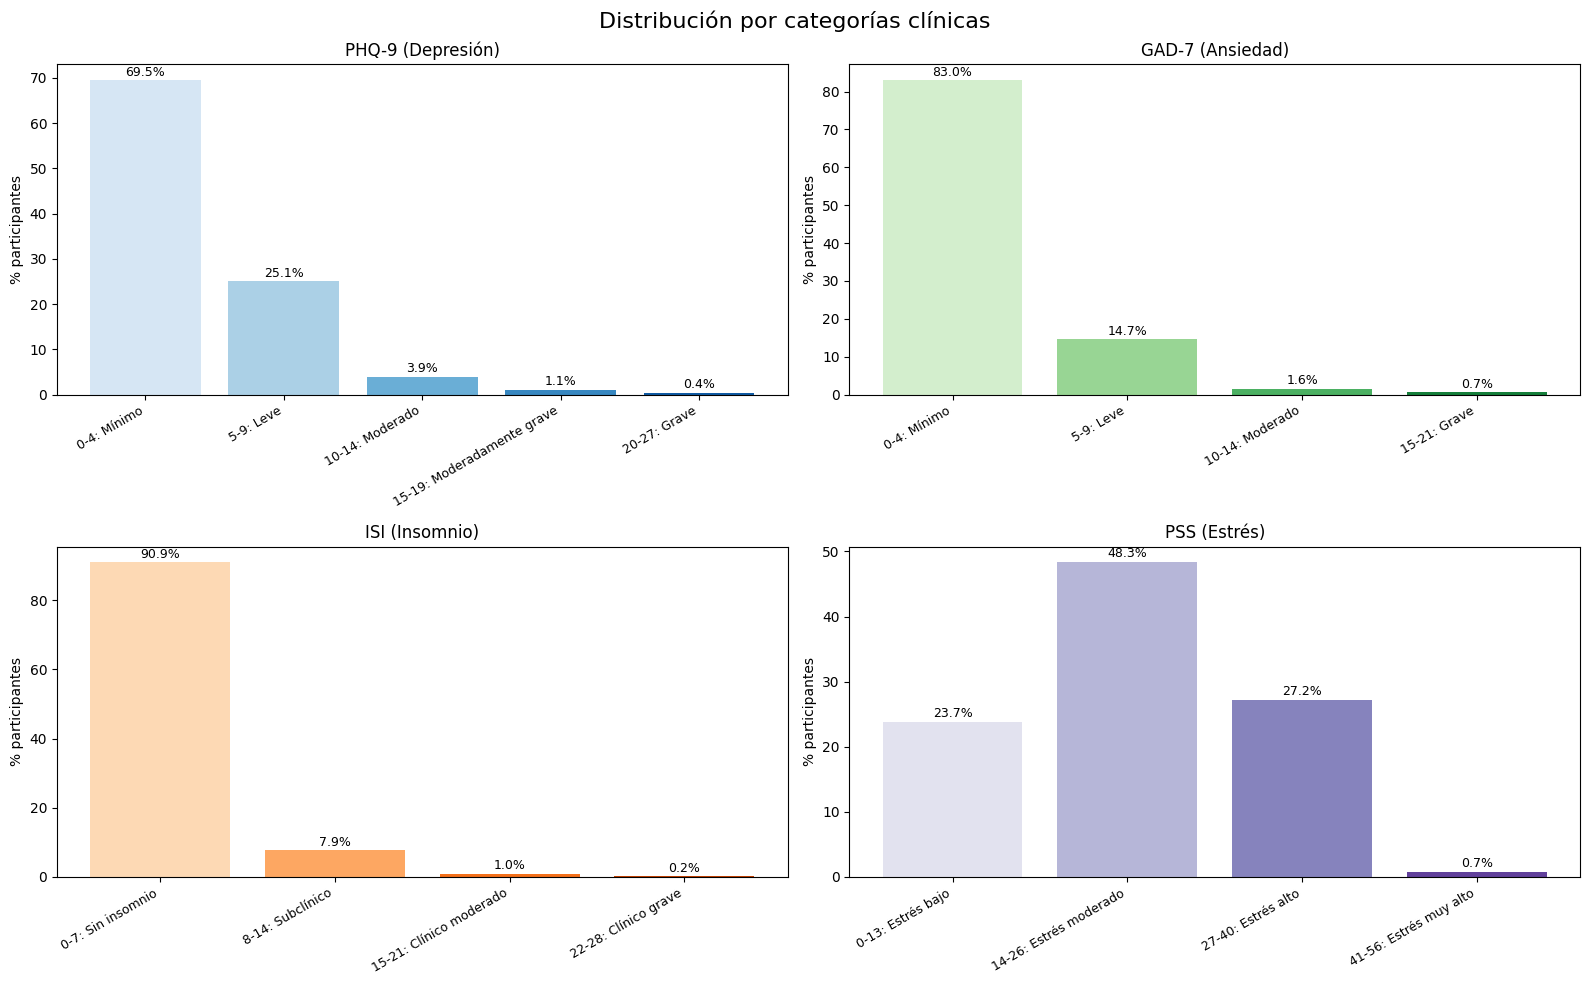

In [36]:
# Categorías clínicas por escala
# Fuente: manuales originales de cada instrumento

def categorizar_phq9(score):
    if score <= 4:   return '0-4: Mínimo'
    elif score <= 9:  return '5-9: Leve'
    elif score <= 14: return '10-14: Moderado'
    elif score <= 19: return '15-19: Moderadamente grave'
    else:             return '20-27: Grave'

def categorizar_gad7(score):
    if score <= 4:   return '0-4: Mínimo'
    elif score <= 9:  return '5-9: Leve'
    elif score <= 14: return '10-14: Moderado'
    else:             return '15-21: Grave'

def categorizar_isi(score):
    if score <= 7:   return '0-7: Sin insomnio'
    elif score <= 14: return '8-14: Subclínico'
    elif score <= 21: return '15-21: Clínico moderado'
    else:             return '22-28: Clínico grave'

def categorizar_pss(score):
    if score <= 13:  return '0-13: Estrés bajo'
    elif score <= 26: return '14-26: Estrés moderado'
    elif score <= 40: return '27-40: Estrés alto'
    else:             return '41-56: Estrés muy alto'

df_phq9['categoria'] = df_phq9['score'].apply(categorizar_phq9)
df_gad7['categoria'] = df_gad7['score'].apply(categorizar_gad7)
df_isi['categoria']  = df_isi['score'].apply(categorizar_isi)
df_pss['categoria']  = df_pss['score'].apply(categorizar_pss)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Distribución por categorías clínicas', fontsize=16)

configs = [
    (df_phq9, 'PHQ-9 (Depresión)', 
     ['0-4: Mínimo','5-9: Leve','10-14: Moderado','15-19: Moderadamente grave','20-27: Grave'], 
     'Blues', axes[0,0]),
    (df_gad7, 'GAD-7 (Ansiedad)',  
     ['0-4: Mínimo','5-9: Leve','10-14: Moderado','15-21: Grave'], 
     'Greens', axes[0,1]),
    (df_isi,  'ISI (Insomnio)',    
     ['0-7: Sin insomnio','8-14: Subclínico','15-21: Clínico moderado','22-28: Clínico grave'], 
     'Oranges', axes[1,0]),
    (df_pss,  'PSS (Estrés)',      
     ['0-13: Estrés bajo','14-26: Estrés moderado','27-40: Estrés alto','41-56: Estrés muy alto'], 
     'Purples', axes[1,1])
]

for df, titulo, orden, palette, ax in configs:
    conteos = df['categoria'].value_counts().reindex(orden)
    porcentajes = conteos / len(df) * 100
    bars = ax.bar(range(len(orden)), porcentajes, 
                  color=sns.color_palette(palette, len(orden)))
    ax.set_xticks(range(len(orden)))
    ax.set_xticklabels(orden, rotation=30, ha='right', fontsize=9)
    ax.set_title(titulo)
    ax.set_ylabel('% participantes')
    for i, (bar, pct) in enumerate(zip(bars, porcentajes)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

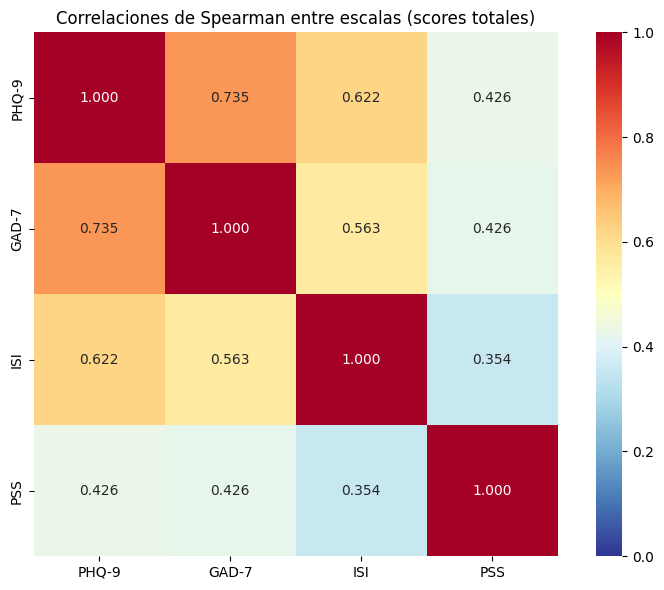

       PHQ-9  GAD-7    ISI    PSS
PHQ-9  1.000  0.735  0.622  0.426
GAD-7  0.735  1.000  0.563  0.426
ISI    0.622  0.563  1.000  0.354
PSS    0.426  0.426  0.354  1.000


In [37]:
# Correlaciones entre scores totales de las cuatro escalas
# Usamos Spearman porque PHQ-9, GAD-7 e ISI son ordinales con distribución sesgada

df_scores = pd.DataFrame({
    'PHQ-9': df_phq9['score'],
    'GAD-7': df_gad7['score'],
    'ISI':   df_isi['score'],
    'PSS':   df_pss['score']
})

corr_matrix = df_scores.corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.3f',
            cmap='RdYlBu_r',
            vmin=0, vmax=1,
            square=True,
            ax=ax)
ax.set_title('Correlaciones de Spearman entre escalas (scores totales)')
plt.tight_layout()
plt.show()

print(corr_matrix.round(3))

## Resumen del EDA — decisiones y hallazgos

### Calidad de los datos
- No hay valores nulos en ningún archivo.
- Los tiempos de respuesta están en segundos, precisión de dos decimales.
- Se detectó un efecto de orientación en el primer ítem de todas las escalas 
  (time1 sistemáticamente más alto), probablemente por adaptación a la interfaz.

### Distribuciones de scores
- PHQ-9, GAD-7 e ISI: distribución fuertemente sesgada a la derecha. 
  Mayoría asintomática (69.5%, 83%, 90.9% en categoría mínima).
- PSS: distribución aproximadamente normal, mediana 20. 
  75% de la muestra con estrés moderado o superior — coherente con contexto COVID.
- Implicación: Spearman es el método de correlación adecuado para las tres 
  primeras escalas. PSS admite ambos métodos.

### Análisis de tiempos — careless responding
- El criterio MAD×5 del paper original detecta solo outliers por tiempo excesivo 
  (cola alta), no por velocidad — el umbral inferior cae en negativo por la 
  asimetría de la distribución.
- Se definió flag_cr por escala combinando: ≥75% de ítems con tiempo <2s 
  y score ≤ umbral proporcional al rango de cada escala.
- Participantes flageados: PHQ-9 9.1% · GAD-7 28.7% · ISI 16.4% · PSS 0.2%
- El flag en GAD-7 debe interpretarse con cautela: alta proporción de 
  asintomáticos genuinos con score 0 contamina el criterio.
- El patrón es más frecuente en hombres (51% sospechosos vs 35% muestra general).
- Decisión: no se eliminan, se marcan para análisis de sensibilidad posterior.

### Correlaciones entre escalas (Spearman, scores totales)
- PHQ-9 ↔ GAD-7: 0.735 — correlación más alta, coherente con comorbilidad 
  depresión-ansiedad.
- PHQ-9 ↔ ISI: 0.622 · GAD-7 ↔ ISI: 0.563 — insomnio más próximo a depresión.
- PSS correlaciones más bajas con todo (0.35-0.43) — constructo más independiente.
- Estructura correlacional confirma que hay señal real para construir la red.

### Próximos pasos
Notebook 02: construcción iterativa de la red.
Iteración 1: PHQ-9 + GAD-7, correlaciones entre ítems, umbral de aristas, 
métricas básicas de grafo.